Simualte PK model only with single dose

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from google.colab import drive
import matplotlib.ticker as ticker
import seaborn as sns

In [ ]:
# 1. Global Parameters & Constants

PK_CONSTANTS = {
   "A1": {"MolMass": 602.58, "Volume": 3690},
   "A2": {"MolMass": 442.32, "Volume": 30446.12},
   "A3": {"MolMass": 291.26, "Volume": 924.6},
   "A4T": {"MolMass": 531.2, "Volume": 1000000}
}

PD_PARAMS = {
   "Emax": 0.99,
   "Hill": 1,
   "c": 15,
   "k": 4,
   "F": 1_000_000
}

# Fixed PK Parameters
FIXED_PK = {
    "k12":22.525296,
    "k23":0.6,
    "kcl1":0.000864,
    "kcl2":9.6,
    "kcl3":6,
    "kcl4":1.0824,
    "k1pt":319.2,
    "k1tp":3.12,
    "k2pt":10.32,
    "k2tp":0.01296,
    "k3tp":0.036,
    "k3pt":1.08,
    "k34":6
}

In [ ]:
# 2. Infusion Logic

def get_infusion_rate(t, dose_mg):
    """
    Translates the Monolix depot() macros into an explicit infusion rate.
    Converts dose from mg to ng.
    """
    dose_ng = dose_mg * 1_000_000

    # Phase 1: Tk0 = 1.91, p = 0.91
    if 0 <= t <= 1.91:
        return (dose_ng * 0.91) / 1.91

    # Phase 2: Tlag = 1.91, Tk0 = 0.09, p = 0.09
    elif 1.91 < t <= 2.0:  # 1.91 + 0.09 = 2.0
        return (dose_ng * 0.09) / 0.09

    # Post-infusion
    else:
        return 0.0

Import relevant parameter and viral load data

In [ ]:
vd_df = pd.read_excel('./ViralDynamicsData_Publication.xlsx')

# Keep only treated individuals and sort for piecewise simulation
treated_df = vd_df[vd_df["treatment_cov"] == 1].copy()
treated_df = treated_df.sort_values(["ID", "time"])
# Load parameter tables
params_df_A1 = pd.read_csv("./estimatedIndividualParameters_A1.txt", sep=',')
params_df_A2 = pd.read_csv("./estimatedIndividualParameters_A2.txt", sep=',')
params_df_A3 = pd.read_csv("./estimatedIndividualParameters_A3.txt", sep=',')
params_df_A4T = pd.read_csv("./estimatedIndividualParameters_A4T.txt", sep=',')

In [ ]:
treated_patients = vd_df[vd_df['treatment'] == 1]['ID'].unique()

Simulate pharmacokinetic model in individual patients and visualize IC50 and epsilon

In [ ]:
def pk_model_only(t, y):
    A1, A1T, A2, A2T, A3, A3T, A4T = y
    A3_safe = max(A3, 0.0)
    ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1
    ddt_A1T = FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T
    ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2
    ddt_A2T = FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T
    ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2
    ddt_A3T = -FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T
    ddt_A4T = FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T

    return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T]

In [ ]:
# Simulation Engine
def simulate_custom_schedule(patient_id, data_df, param_A1, param_A2, param_A3, param_A4T, nominal_schedule, t_eval_grid):
    """
    Executes synchronized ODE integration for a specific patient biology
    driven by a custom nominal dosing schedule.
    """
    pt_data = data_df[data_df['ID'] == patient_id].copy()

    # Extract baseline IC50 parameters safely
    IC50_A1 = param_A1[param_A1['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A2 = param_A2[param_A2['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A3 = param_A3[param_A3['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A4T = param_A4T[param_A4T['id'] == patient_id]['IC50_mode'].values[0]

    # Initialize 7 states for the updated PK model: A1, A1T, A2, A2T, A3, A3T, A4T
    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    # Execute step-by-step nominal loading intervals
    for i, (t_event, dose_mg) in enumerate(nominal_schedule):
        y0[0] += dose_mg * PD_PARAMS['F']

        # DYNAMIC INTERVAL FIX: Look ahead to the next dose to determine integration window
        if i + 1 < len(nominal_schedule):
            next_time = nominal_schedule[i+1][0]
        else:
            # For the last dose, simulate forward by the length of the previous interval
            interval = t_event - nominal_schedule[i-1][0] if i > 0 else 1.0
            next_time = t_event + interval

        # Inject dense integration nodes post-bolus to cleanly map exact Cmax peaks
        t_dense = np.concatenate([
            np.linspace(current_time, current_time + 0.01, 50),
            np.linspace(current_time + 0.01, next_time, 150)
        ])

        sol = solve_ivp(
            fun=pk_model_only, t_span=(current_time, next_time), y0=y0,
            t_eval=np.unique(t_dense), method='LSODA'
        )
        t_out.append(sol.t[:-1])
        y_out.append(sol.y[:, :-1])
        y0 = sol.y[:, -1]
        current_time = next_time

    # 5-Day Washout tracking tail
    t_tail = np.linspace(current_time, current_time + 5.0, 500)
    sol_tail = solve_ivp(
        fun=pk_model_only, t_span=(current_time, current_time + 5.0), y0=y0,
        t_eval=t_tail, method='LSODA'
    )
    t_out.append(sol_tail.t)
    y_out.append(sol_tail.y)

    t_raw = np.concatenate(t_out)
    y_raw = np.concatenate(y_out, axis=1)

    # Process system metrics
    concs, epsilons = {}, {}
    ic50_ngml = {}

    # State indices: A1 = 0, A2 = 2, A3 = 4, A4T = 6
    compartment_map = [
        ("A1", 0, IC50_A1),
        ("A2", 2, IC50_A2),
        ("A3", 4, IC50_A3),
        ("A4T", 6, IC50_A4T)
    ]

    for comp, idx, ic50_val in compartment_map:
        amt = y_raw[idx]
        vol = PK_CONSTANTS[comp]["Volume"]
        mass = PK_CONSTANTS[comp]["MolMass"]

        c_ng = amt / vol
        ic50_ngml[comp] = ic50_val * mass
        cc = amt / (vol * mass)
        eps = PD_PARAMS["Emax"] * (cc**PD_PARAMS["Hill"]) / ((cc**PD_PARAMS["Hill"]) + (ic50_val**PD_PARAMS["Hill"]))

        # Interpolate onto target synchronized grid
        f_c = interp1d(t_raw, c_ng, bounds_error=False, fill_value=(0.0, 0.0))
        f_e = interp1d(t_raw, eps, bounds_error=False, fill_value=(0.0, 0.0))
        concs[comp] = f_c(t_eval_grid)
        epsilons[comp] = f_e(t_eval_grid)

    return concs, epsilons, ic50_ngml

In [ ]:
# Figure Generator
def plot_6panel_dosing_dashboard_small(subtitle_label, title, t_grid, c_base, e_base, c_test, e_test, test_label, color_test):
    """
    3x2 6-panel dashboard.
    """
    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'font.size': TINY_SIZE,
        'axes.labelsize': SMALL_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'legend.fontsize': TINY_SIZE,
        'figure.titlesize': SMALL_SIZE,
        'axes.labelweight': 'normal',
        'axes.titleweight': 'normal'
    })

    fig, axes = plt.subplots(3, 2, figsize=(4.5, 4.5), dpi=300)

    # Panel label formatting
    panel_label_args = {
        'fontsize': SMALL_SIZE,
        'fontweight': 'bold',
        'va': 'bottom',
        'ha': 'right'
    }

    lw = 0.7
    ms = 0.2

    x_ticks = np.arange(0, max(t_grid) + 1, 5)

    def format_panel(ax, ylabel, yscale='log', show_x_label=False):
        ax.set_ylabel(ylabel)
        if yscale == 'log':
            ax.set_yscale('log')
        else:
            ax.set_ylim(0, 1.05)

        ax.set_xticks(x_ticks)
        ax.grid(True, alpha=0.3)

        if show_x_label:
            ax.set_xlabel("Time (days)")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

    # ROW 1: A1 & A2 Concentrations
    # PANEL I: A1
    ax0 = axes[0, 0]
    ax0.plot(t_grid, c_base["A1"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax0.plot(t_grid, c_test["A1"], color=color_test, linestyle="--", linewidth=lw, marker='o', markersize=ms)
    format_panel(ax0, "A1 (ng/mL)", yscale='log', show_x_label=False)
    ax0.set_ylim(bottom=1e-2)
    ax0.text(-0.2, 1.05, "I", transform=ax0.transAxes, **panel_label_args)

    # PANEL II: A2
    ax1 = axes[0, 1]
    ax1.plot(t_grid, c_base["A2"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax1.plot(t_grid, c_test["A2"], color=color_test, linestyle="--", linewidth=lw, marker='o', markersize=ms)
    format_panel(ax1, "A2 (ng/mL)", yscale='log', show_x_label=False)
    ax1.text(-0.2, 1.05, "II", transform=ax1.transAxes, **panel_label_args)

    # ROW 2: A3 & A4T Concentrations
    # PANEL III: A3
    ax2 = axes[1, 0]
    ax2.plot(t_grid, c_base["A3"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax2.plot(t_grid, c_test["A3"], color=color_test, linestyle="--", linewidth=lw, marker='o', markersize=ms)
    format_panel(ax2, "A3 (ng/mL)", yscale='log', show_x_label=False)
    ax2.text(-0.2, 1.05, "III", transform=ax2.transAxes, **panel_label_args)

    # PANEL IV: A4T
    ax3 = axes[1, 1]
    ax3.plot(t_grid, c_base["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax3.plot(t_grid, c_test["A4T"], color=color_test, linestyle="--", linewidth=lw, marker='o', markersize=ms)
    format_panel(ax3, "A4T (ng/mL)", yscale='log', show_x_label=False)
    ax3.text(-0.2, 1.05, "IV", transform=ax3.transAxes, **panel_label_args)

    # ROW 3: A4T Efficacy & Blank
    # PANEL V: A4T Efficacy
    ax4 = axes[2, 0]
    ax4.plot(t_grid, e_base["A4T"], color="black", linewidth=lw, marker='o', markersize=ms)
    ax4.plot(t_grid, e_test["A4T"], color=color_test, linestyle="--", linewidth=lw, marker='o', markersize=ms)
    format_panel(ax4, r"A4T Efficacy ($\epsilon$)", yscale='linear', show_x_label=True)
    ax4.text(-0.2, 1.05, "V", transform=ax4.transAxes, **panel_label_args)

    # Legend on Panel V (ax4)
    ax4.legend(["Reg. Dose", test_label], loc="lower right", bbox_to_anchor=(0.95, 0), frameon=False)

    # PANEL VI: Blank white space
    ax5 = axes[2, 1]
    ax5.axis('off')  # Hides the axes and leaves the space completely blank

    # Tight spacing
    plt.tight_layout(pad=0.5)
    plt.show()
    plt.rcdefaults()

Sensitivity analysis: Double dose amount for each dose

In [ ]:
# Execution Wrappers for Cohort Analysis
def run_double_dose_analysis_cohort_6panel(patient_ids, data_df, param_A1, param_A2, param_A3, param_A4T):
    """
    Executes the Double Dose Amount scenario across a list of patients
    and plots the median response for the cohort in a 6-panel layout.
    """
    base_grid = np.linspace(0, 10, 2000)
    injection_points = np.array([0.0, 0.001, 0.005, 1.0, 1.001, 2.0, 2.001, 3.0, 3.001, 4.0, 4.001])
    t_aligned = np.unique(np.sort(np.concatenate([base_grid, injection_points])))

    regimen_base = [(0.0, 200.0), (1.0, 100.0), (2.0, 100.0), (3.0, 100.0), (4.0, 100.0)]
    # Double Dose: 400mg load + 200mg daily
    regimen_high = [(0.0, 400.0), (1.0, 200.0), (2.0, 200.0), (3.0, 200.0), (4.0, 200.0)]

    # Dictionaries to aggregate simulation outputs across the cohort
    agg_c_base = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_e_base = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_c_high = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_e_high = {"A1": [], "A2": [], "A3": [], "A4T": []}

    # Run ODE solver for every patient in the cohort
    for pid in patient_ids:
        c_b, e_b, _ = simulate_custom_schedule(pid, data_df, param_A1, param_A2, param_A3, param_A4T, regimen_base, t_aligned)
        c_h, e_h, _ = simulate_custom_schedule(pid, data_df, param_A1, param_A2, param_A3, param_A4T, regimen_high, t_aligned)

        for comp in ["A1", "A2", "A3", "A4T"]:
            agg_c_base[comp].append(c_b[comp])
            agg_e_base[comp].append(e_b[comp])
            agg_c_high[comp].append(c_h[comp])
            agg_e_high[comp].append(e_h[comp])

    # Calculate the median across the cohort at every time step (axis=0)
    med_c_base = {comp: np.median(agg_c_base[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_e_base = {comp: np.median(agg_e_base[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_c_high = {comp: np.median(agg_c_high[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_e_high = {comp: np.median(agg_e_high[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}

    # Render the plot using the aggregated medians
    plot_6panel_dosing_dashboard_small(
        "Treatment Arm (Median)", # Passes to subtitle
        "Dosing Sensitivity: Double Dose Amount",
        t_aligned, med_c_base, med_e_base, med_c_high, med_e_high,
        "2x Dose", "dodgerblue"
    )

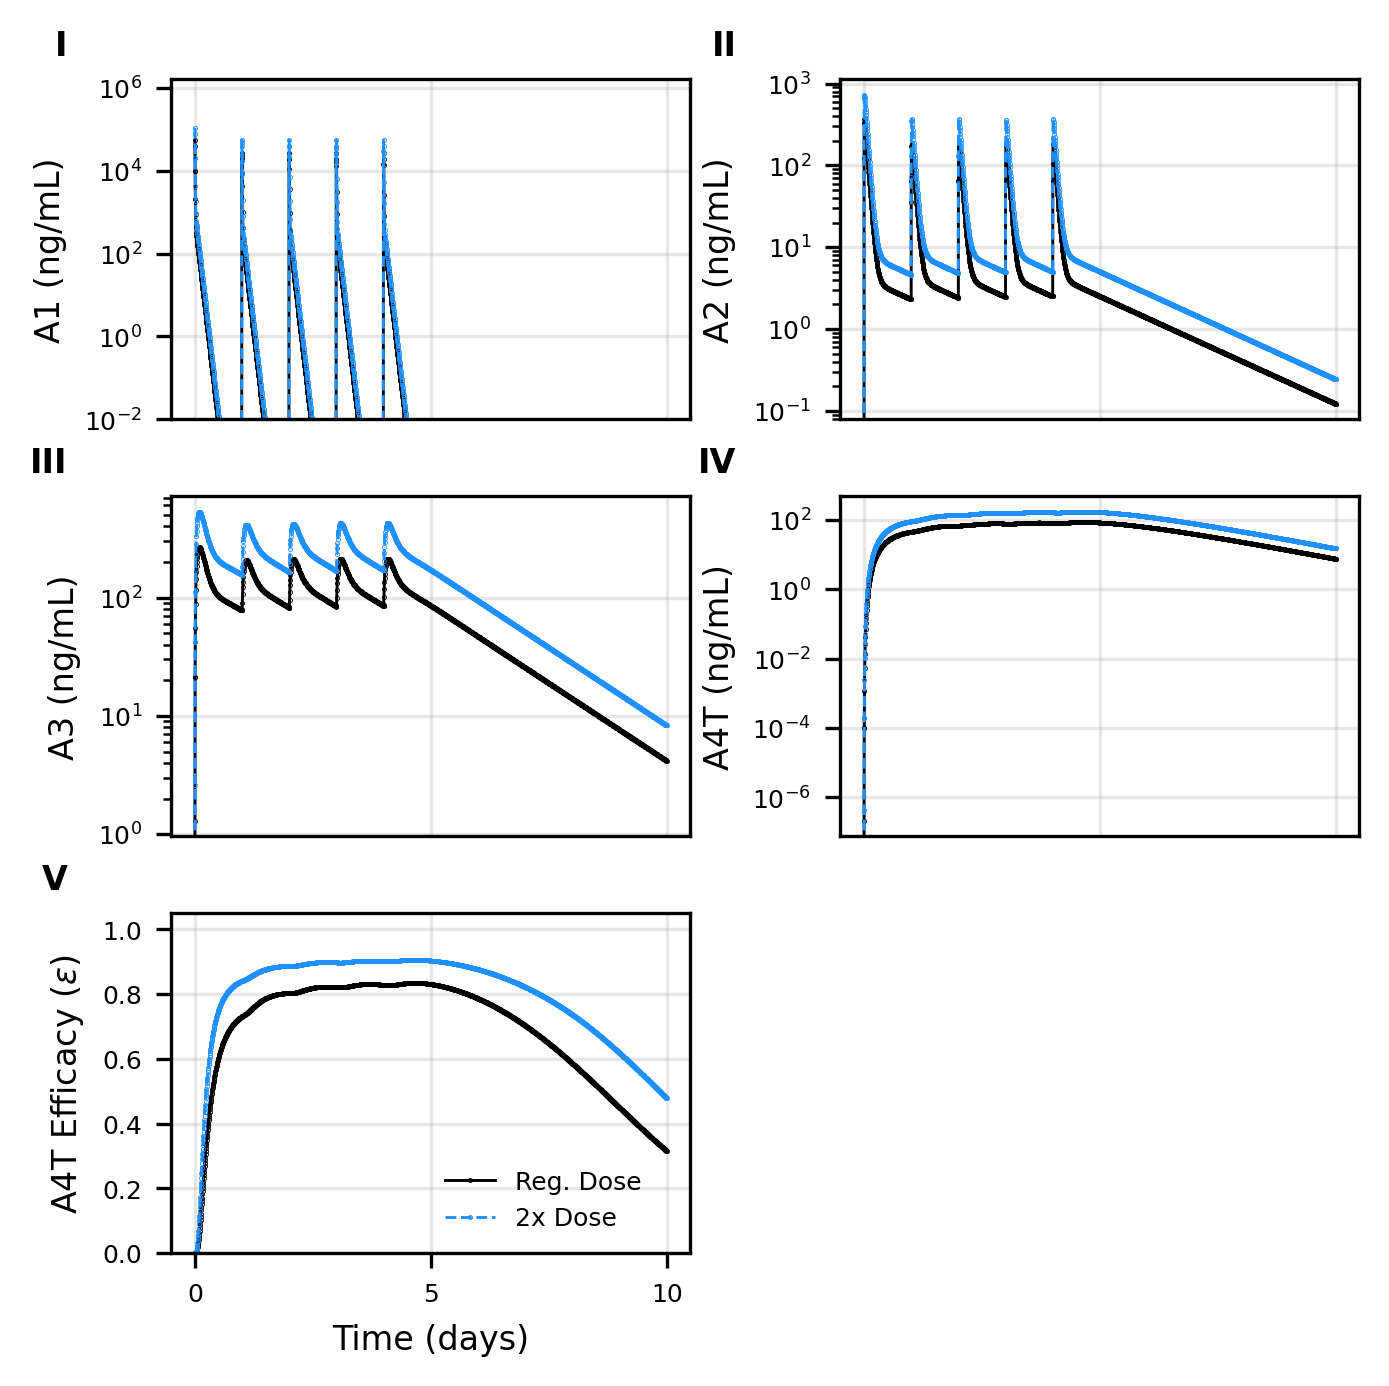

In [ ]:
run_double_dose_analysis_cohort_6panel(
    treated_patients,
    vd_df,
    params_df_A1,
    params_df_A2,
    params_df_A3,
    params_df_A4T
)

Sensitivity analysis: Double dosing frequency for 5 day regimen

In [ ]:
def run_double_freq_analysis_cohort_6panel(patient_ids, data_df, param_A1, param_A2, param_A3, param_A4T):
    """
    Executes the Double Dose Frequency (q12h) scenario across a list of patients
    and plots the median response for the cohort in a 6-panel layout.
    """
    # 1. Define simulation time grid tailored for half-day spikes
    base_grid = np.linspace(0, 8, 2500)
    all_dosing_knots = np.arange(0.0, 5.0, 0.5)

    # Inject high-resolution points immediately after each potential dose
    injection_points = np.concatenate([
        all_dosing_knots,
        all_dosing_knots + 0.001,
        all_dosing_knots + 0.005
    ])
    t_aligned = np.unique(np.sort(np.concatenate([base_grid, injection_points])))

    # 2. Construct Treatment Regimens
    regimen_base = [(0.0, 200.0), (1.0, 100.0), (2.0, 100.0), (3.0, 100.0), (4.0, 100.0)]

    # Double Frequency: q12h dosing (Day 0.5, 1.0, 1.5, ..., 4.5)
    regimen_freq = [(0.0, 200.0)] + [(day, 100.0) for day in np.arange(0.5, 5.0, 0.5)]

    # 3. Dictionaries to aggregate simulation outputs across the cohort
    agg_c_base = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_e_base = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_c_freq = {"A1": [], "A2": [], "A3": [], "A4T": []}
    agg_e_freq = {"A1": [], "A2": [], "A3": [], "A4T": []}

    # 4. Run ODE solver for every patient in the cohort
    for pid in patient_ids:
        c_b, e_b, _ = simulate_custom_schedule(pid, data_df, param_A1, param_A2, param_A3, param_A4T, regimen_base, t_aligned)
        c_f, e_f, _ = simulate_custom_schedule(pid, data_df, param_A1, param_A2, param_A3, param_A4T, regimen_freq, t_aligned)

        for comp in ["A1", "A2", "A3", "A4T"]:
            agg_c_base[comp].append(c_b[comp])
            agg_e_base[comp].append(e_b[comp])
            agg_c_freq[comp].append(c_f[comp])
            agg_e_freq[comp].append(e_f[comp])

    # 5. Calculate the median across the cohort at every time step (axis=0)
    med_c_base = {comp: np.median(agg_c_base[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_e_base = {comp: np.median(agg_e_base[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_c_freq = {comp: np.median(agg_c_freq[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}
    med_e_freq = {comp: np.median(agg_e_freq[comp], axis=0) for comp in ["A1", "A2", "A3", "A4T"]}

    # 6. Render the plot using the aggregated medians
    plot_6panel_dosing_dashboard_small(
        "Treatment Arm (Median)", # Subtitle
        "Dosing Sensitivity: Double Dose Frequency (q12h)",
        t_aligned, med_c_base, med_e_base, med_c_freq, med_e_freq,
        "2x Freq", "mediumpurple"
    )

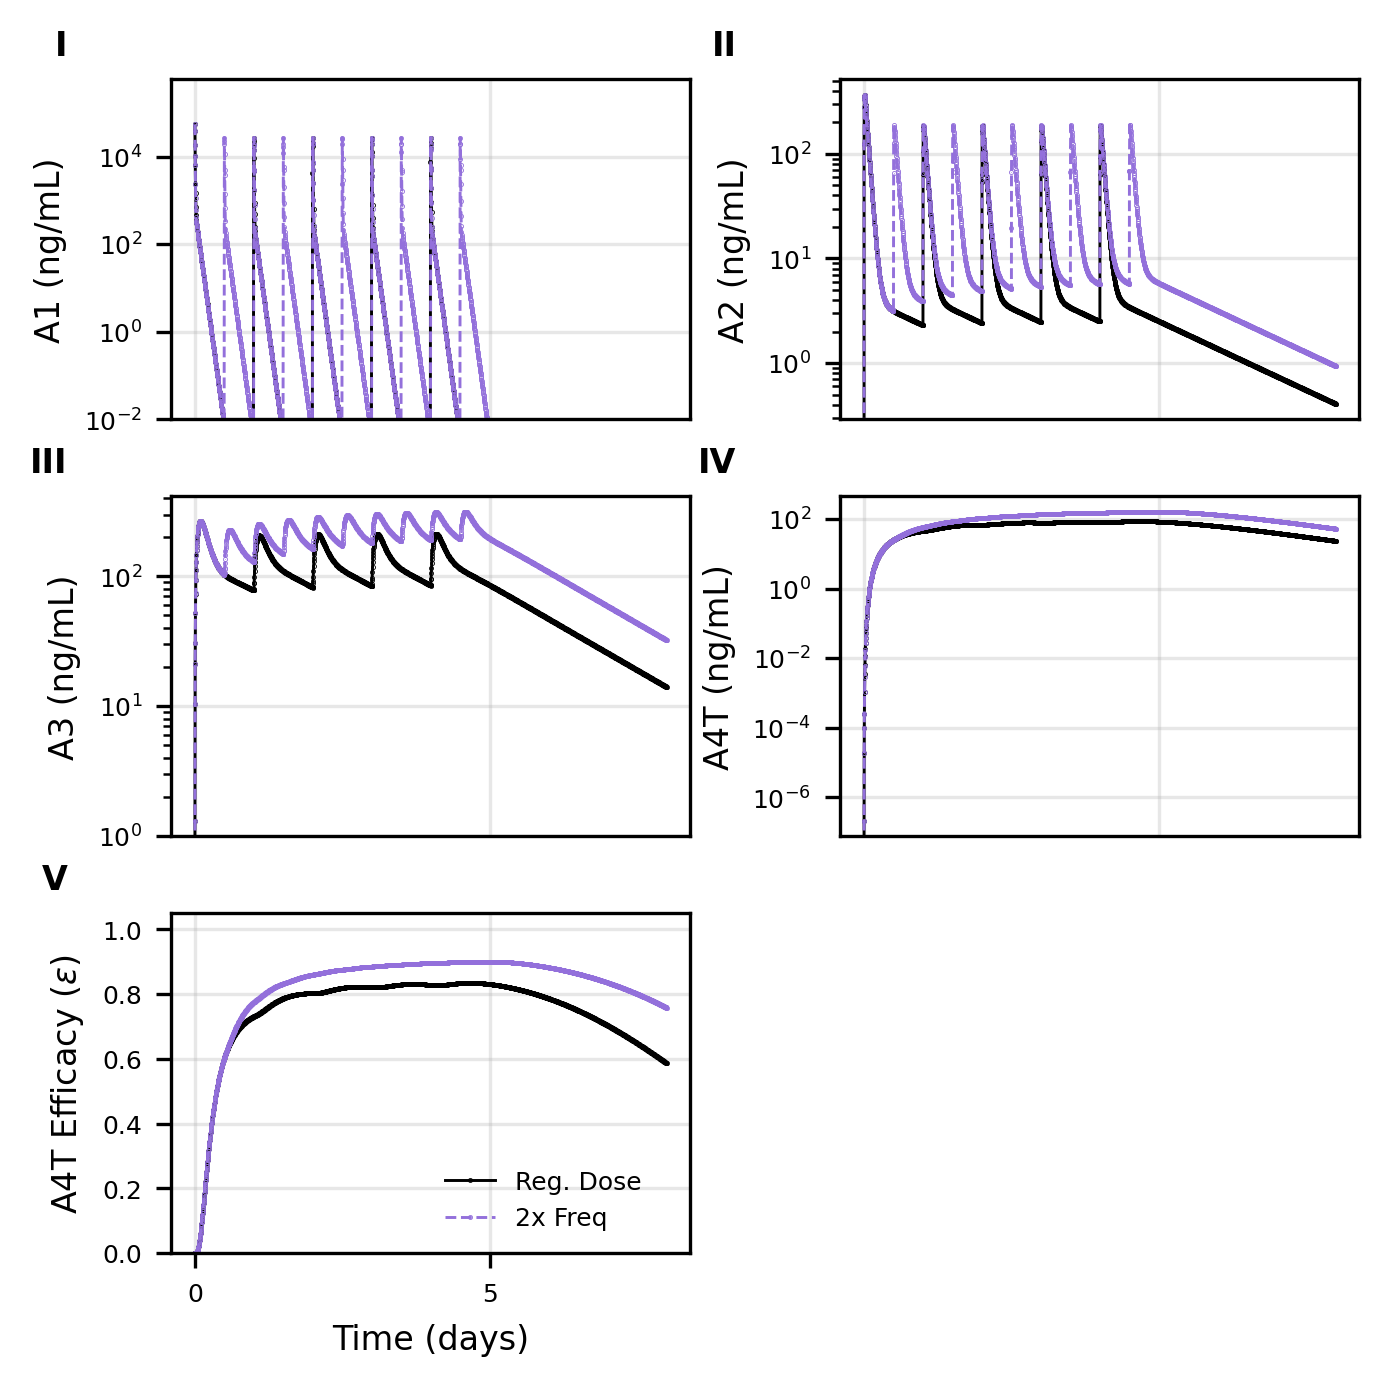

In [ ]:
run_double_freq_analysis_cohort_6panel(
    treated_patients,
    vd_df,
    params_df_A1,
    params_df_A2,
    params_df_A3,
    params_df_A4T
)

Compare average drug efficacy over treatment time for two treatment regimes tested in sensitivity analysis and baseline treatment regimen

In [ ]:
def compute_treatment_averaged_epsilon(patient_id, data_df, param_A1, param_A2, param_A3, param_A4T, schedule):
    """
    Executes an ODE simulation driven by a custom schedule array and evaluates the
    time-averaged epsilon strictly over the standardized 5-day active clinical window.
    """
    pt_data = data_df[data_df['ID'] == patient_id].copy()

    # Extract structural IC50 boundaries
    IC50_A1 = param_A1[param_A1['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A2 = param_A2[param_A2['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A3 = param_A3[param_A3['id'] == patient_id]['IC50_mode'].values[0]
    IC50_A4T = param_A4T[param_A4T['id'] == patient_id]['IC50_mode'].values[0]

    # Ensure schedule array is sorted chronologically
    sorted_schedule = sorted(schedule, key=lambda x: x[0])
    num_doses = len(sorted_schedule)

    y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    t_out, y_out = [], []
    current_time = 0.0

    # Execute piecewise schedule integrations
    for i in range(num_doses):
        t_event, dose_mg = sorted_schedule[i]
        y0[0] += dose_mg * PD_PARAMS['F']

        # Determine strict integration target bound
        next_time = sorted_schedule[i+1][0] if i < num_doses - 1 else t_event + 1.0

        if next_time > current_time:
            # Construct granular integration segments with high density post-bolus
            dense_span = min(0.01, (next_time - current_time) / 3.0)
            t_eval = np.concatenate([
                np.linspace(current_time, current_time + dense_span, 30),
                np.linspace(current_time + dense_span, next_time, 120)
            ])

            sol = solve_ivp(
                fun=pk_model_only, t_span=(current_time, next_time), y0=y0,
                t_eval=np.unique(t_eval), method='LSODA'
            )
            t_out.append(sol.t[:-1])
            y_out.append(sol.y[:, :-1])
            y0 = sol.y[:, -1]
            current_time = next_time

    # Simulate terminal tracking segment to clear the standard 5-day boundary safely
    if current_time < 5.0:
        sol_tail = solve_ivp(
            fun=pk_model_only, t_span=(current_time, 5.0), y0=y0,
            t_eval=np.linspace(current_time, 5.0, 200), method='LSODA'
        )
        t_out.append(sol_tail.t)
        y_out.append(sol_tail.y)
    else:
        # If schedule extended past Day 5.0 natively, cap final loop block
        t_out.append(np.array([current_time]))
        y_out.append(y0.reshape(-1, 1))

    t_raw = np.concatenate(t_out)
    y_raw = np.concatenate(y_out, axis=1)

    # Apply strict evaluation mask isolates exactly Days 0.0 to 5.0
    mask = (t_raw >= 0.0) & (t_raw <= 5.0)
    t_window = t_raw[mask]
    y_window = y_raw[:, mask]
    window_duration = t_window[-1] - t_window[0]

    # Process time-averaged metrics per spatial volume
    avg_epsilons = {}

    compartment_map = [("A1", 0, IC50_A1), ("A2", 2, IC50_A2), ("A3", 4, IC50_A3), ("A4T", 6, IC50_A4T)]
    for comp, idx, ic50_val in compartment_map:
        amt = y_window[idx]
        vol = PK_CONSTANTS[comp]["Volume"]
        mass = PK_CONSTANTS[comp]["MolMass"]

        # Calculate continuous inhibitory effect vectors
        cc = amt / (vol * mass)
        eps_trace = PD_PARAMS["Emax"] * (cc**PD_PARAMS["Hill"]) / ((cc**PD_PARAMS["Hill"]) + (ic50_val**PD_PARAMS["Hill"]))

        # Execute trapezoidal integration across the precise temporal denominator
        if window_duration > 0:
            avg_epsilons[comp] = np.trapz(eps_trace, t_window) / window_duration
        else:
            avg_epsilons[comp] = 0.0

    return avg_epsilons

In [ ]:
def extract_cohort_efficacy_distributions(patient_id_array, data_df, param_A1, param_A2, param_A3, param_A4T):
    # Standardize Nominal Protocols
    regimen_base = [(0.0, 200.0), (1.0, 100.0), (2.0, 100.0), (3.0, 100.0), (4.0, 100.0)]
    regimen_double = [(0.0, 400.0), (1.0, 200.0), (2.0, 200.0), (3.0, 200.0), (4.0, 200.0)]
    regimen_freq = [
      (0.0, 200.0), (0.5, 100.0), (1.0, 100.0), (1.5, 100.0),
      (2.0, 100.0), (2.5, 100.0), (3.0, 100.0), (3.5, 100.0),
      (4.0, 100.0), (4.5, 100.0)
    ]

    protocols = [
        ("Baseline", regimen_base),
        ("Double Dose", regimen_double),
        ("High Frequency", regimen_freq)
    ]

    records = []
    print(f"Evaluating multi-regimen efficacy bounds across {len(patient_id_array)} patient biologies...")

    for pt_id in patient_id_array:
        for regimen_name, schedule_array in protocols:
            eps_res = compute_treatment_averaged_epsilon(
                pt_id, data_df, param_A1, param_A2, param_A3, param_A4T, schedule_array
            )

            # Map outputs to structured evaluation format (A4T ONLY)
            records.append({
                "Patient_ID": pt_id,
                "Regimen": regimen_name,
                "Compartment": "A4T (GS-443902)",
                "Time_Averaged_Epsilon": eps_res["A4T"]
            })

    return pd.DataFrame(records)

In [ ]:
# Execution
df_distribution = extract_cohort_efficacy_distributions(treated_patients, vd_df, params_df_A1, params_df_A2, params_df_A3, params_df_A4T)
mapping = {'Baseline': 'Reg. Dose', 'Double Dose': '2x Dose', 'High Frequency': '2x Freq.'}
df_distribution['Regimen'] = df_distribution['Regimen'].map(mapping)

Evaluating multi-regimen efficacy bounds across 67 patient biologies...


/tmp/ipykernel_1717/1427525171.py:89: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  avg_epsilons[comp] = np.trapz(eps_trace, t_window) / window_duration


In [ ]:
# Cohort Aggregation & Regimen Comparison

# Group by 'Regimen' and calculate the mean of the efficacy column
mean_efficacy_by_regimen = df_distribution.groupby('Regimen')['Time_Averaged_Epsilon'].mean().reset_index()

# Rename the aggregated column for clarity
mean_efficacy_by_regimen.rename(
    columns={'Time_Averaged_Epsilon': 'Mean_Cohort_Epsilon'},
    inplace=True
)

# Sort the results to easily see which regimen performed best
mean_efficacy_by_regimen = mean_efficacy_by_regimen.sort_values(
    by='Mean_Cohort_Epsilon',
    ascending=False
)

print("\n--- Mean Time-Averaged Efficacy by Regimen ---")
print(mean_efficacy_by_regimen.to_string(index=False))


--- Mean Time-Averaged Efficacy by Regimen ---
  Regimen  Mean_Cohort_Epsilon
  2x Dose             0.830501
 2x Freq.             0.793470
Reg. Dose             0.744431


In [ ]:
# Distribution Visualizer
def plot_multi_regimen_efficacy_distributions(df_results):
    """
    Renders faceted violin + strip overlays to visualize population
    distribution shifts across all target dosing strategies.
    Optimized for small, high-resolution scientific publication figures.
    """

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'figure.dpi': 300,
        'savefig.dpi': 300,

        'font.size': SMALL_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'axes.labelsize': MEDIUM_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'legend.fontsize': TINY_SIZE,
        'legend.title_fontsize': SMALL_SIZE,
        'axes.titleweight': 'normal',
        'axes.labelweight': 'normal'
    })

    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=df_results,
        x="Regimen",
        y="Time_Averaged_Epsilon",
        col="Compartment",
        kind="violin",
        inner=None,
        palette="pastel",
        cut=0,
        height=2.1,
        aspect=2.2 / 2.1,
        sharey=True
    )

    g.set_titles("{col_name}")


    g.map_dataframe(
        sns.stripplot,
        x="Regimen",
        y="Time_Averaged_Epsilon",
        jitter=0.12,
        alpha=0.7,
        size=2.0,
        color="black",
        linewidth=0.3,
        edgecolor="white"
    )


    g.fig.set_size_inches(2.2, 2.1)
    g.fig.set_dpi(300)


    for i, ax in enumerate(g.axes.flat):

        ax.set_ylim(0.4, 1)

        if i == 0:
            ax.set_ylabel(
                r"Average Efficacy ($\bar{\epsilon}$)",
                fontsize=SMALL_SIZE
            )
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")

        ax.tick_params(
            axis='x',
            labelsize=TINY_SIZE,
            rotation=25,
            width=0.5,
            length=2
        )

        ax.tick_params(
            axis='y',
            labelsize=TINY_SIZE,
            width=0.5,
            length=2
        )

        # Subplot titles
        ax.title.set_fontsize(SMALL_SIZE)
        ax.title.set_fontweight('normal')

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    plt.tight_layout(pad=0.3)

    plt.show()

    # Reset defaults
    plt.rcdefaults()

/tmp/ipykernel_1717/86781463.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


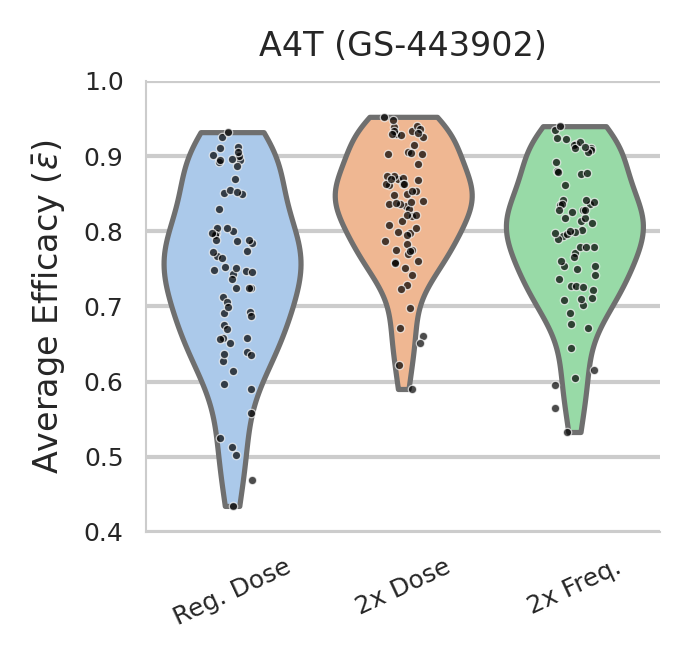

In [ ]:
plot_multi_regimen_efficacy_distributions(df_distribution)

Viral load reduction comparison across two treatment regimens tested in sensitivity analysis and baseline treatment regimen

In [ ]:
platcov_df = vd_df[vd_df['Study'] == 'Platcov'].copy()
treated_patients = platcov_df[platcov_df['treatment'] == 1]['ID'].unique()
untreated_patients = platcov_df[platcov_df['treatment'] == 0]['ID'].unique()

In [ ]:
def viral_dynamic_model(t, y, target_cpt, params, dynamic_inputs):
  """
  Combined PK/PD and Viral Dynamics ODE system.
  """
  A1, A1T, A2, A2T, A3, A3T, A4T, T, R, E, I, V = y

  # Unpack dynamic input
  treatment = dynamic_inputs['treatment']

  # Unpack VD parameters
  beta = params['beta']
  pi = params['pi']
  rho = params['rho']
  phi = params['phi']
  delta = params['delta']
  m = params['m']
  tau = params['tau']
  IC50 = params['IC50']

  # --- PK Model ---
  ddt_A1 = FIXED_PK['k1tp']*A1T - (FIXED_PK['k1pt'] + FIXED_PK['k12'] + FIXED_PK['kcl1'])*A1

  ddt_A2 = FIXED_PK['k12']*A1 + FIXED_PK['k2tp']*A2T - (FIXED_PK['k2pt'] + FIXED_PK['kcl2'] + FIXED_PK['k23'])*A2

  ddt_A3 = FIXED_PK['k3tp']*A3T - (FIXED_PK['kcl3'] + FIXED_PK['k3pt'])*A3 + FIXED_PK['k23']*A2

  ddt_A1T = (FIXED_PK['k1pt']*A1 - FIXED_PK['k1tp']*A1T - FIXED_PK['k12']*A1T)

  ddt_A2T = (FIXED_PK['k2pt']*A2 + FIXED_PK['k12']*A1T - FIXED_PK['k23']*A2T - FIXED_PK['k2tp']*A2T)

  ddt_A3T = (-FIXED_PK['k3tp']*A3T + FIXED_PK['k23']*A2T + FIXED_PK['k3pt']*A3 - FIXED_PK['k34']*A3T)

  ddt_A4T = (FIXED_PK['k34']*A3T - FIXED_PK['kcl4']*A4T)

  # --- PD Effect (epsilon) ---
  # Calculate Concentration based on target compartment
  if target_cpt == "A1":
      Cc = A1 / (PK_CONSTANTS["A1"]["Volume"] * PK_CONSTANTS["A1"]["MolMass"])
  elif target_cpt == "A2":
      Cc = A2 / (PK_CONSTANTS["A2"]["Volume"] * PK_CONSTANTS["A2"]["MolMass"])
  elif target_cpt == "A3":
      Cc = A3 / (PK_CONSTANTS["A3"]["Volume"] * PK_CONSTANTS["A3"]["MolMass"])
  elif target_cpt == "A4T":
      Cc = A4T / (PK_CONSTANTS["A4T"]["Volume"] * PK_CONSTANTS["A4T"]["MolMass"])
  else:
      Cc = 0

  if treatment == 0:
      epsilon = 0
  else:
      # Prevent division by zero
      if Cc <= 0:
          epsilon = 0
      else:
          epsilon = PD_PARAMS['Emax'] * (Cc**PD_PARAMS['Hill']) / ((Cc**PD_PARAMS['Hill']) + (IC50**PD_PARAMS['Hill']))

  # --- Viral Dynamics ---
  eps = m if t > tau else 0

  ddt_T = -beta * T * V - phi * I * T + rho * R
  ddt_R = phi * I * T - rho * R
  ddt_E = beta * T * V - PD_PARAMS['k'] * E
  ddt_I = PD_PARAMS['k'] * E - delta * I - eps * I

  # Enforce that infected cells do not produce virus until there is at least 1
  if I >= 1:
      temp = pi * (1 - epsilon) * I - PD_PARAMS['c'] * V
  else:
      temp = -PD_PARAMS['c'] * V

  ddt_V = temp

  return [ddt_A1, ddt_A1T, ddt_A2, ddt_A2T, ddt_A3, ddt_A3T, ddt_A4T, ddt_T, ddt_R, ddt_E, ddt_I, ddt_V]

In [ ]:
def simulate_regimen_viral_load_corr(patient_id, data_df, param_df, regimen, target_cpt="A4T"):
    """
    Executes piecewise integration of the viral dynamic model for a single patient
    using a custom, idealized dosing regimen schedule.
    """
    # 1. Parameter Extraction
    p_row = param_df[param_df['id'] == patient_id].iloc[0]
    params = {
        'beta': 10 ** p_row['log10beta_mode'], 'pi': 10 ** p_row['log10pi_mode'],
        'rho': 10 ** p_row['log10rho_mode'], 'phi': 10 ** p_row['log10phi_mode'],
        'delta': p_row['delta_mode'], 'm': p_row['m_mode'], 'tau': p_row['tau_mode'],
        'tzero': p_row['tzero_mode'], 'Vzero': p_row['Vzero_mode'], 'IC50': p_row['IC50_mode']
    }

    # Extract baseline active inputs
    active_inputs = {
      'treatment': 0
    }

    # y0 expanded to 12 states to include A4T
    y0 = [0, 0, 0, 0, 0, 0, 0, 1e7, 0, 0, 0, params['Vzero']]
    current_time = -params['tzero']

    t_out, y_out = [], []

    # 2. Integrate Pre-Treatment Window (t_start to Day 0)
    if current_time < 0:
        t_eval = np.linspace(current_time, 0, max(50, int((0 - current_time) * 100)))
        sol = solve_ivp(
            fun=viral_dynamic_model,
            t_span=(current_time, 0),
            y0=y0,
            t_eval=t_eval,
            args=(target_cpt, params, active_inputs),
            method='LSODA',
            max_step=0.1
        )
        t_out.append(sol.t)
        y_out.append(sol.y)
        y0 = sol.y[:, -1].copy()
        current_time = 0.0

    active_inputs['treatment'] = 1

    # 3. Execute Custom Dosing Regimen
    for t_event, dose_mg in regimen:
        if t_event > current_time:
            t_eval = np.linspace(current_time, t_event, max(50, int((t_event - current_time) * 100)))
            sol = solve_ivp(
                fun=viral_dynamic_model,
                t_span=(current_time, t_event),
                y0=y0,
                t_eval=t_eval,
                args=(target_cpt, params, active_inputs),
                method='LSODA',
                max_step=0.1
            )
            t_out.append(sol.t)
            y_out.append(sol.y)
            y0 = sol.y[:, -1].copy()
            current_time = t_event

        if dose_mg > 0:
            y0[0] += dose_mg * PD_PARAMS['F']

    # 4. Conclude Simulation to Day 8 (or slightly past the last regimen dose)
    t_final = max(8.0, current_time + 1.0)
    if t_final > current_time:
        sol = solve_ivp(
            fun=viral_dynamic_model,
            t_span=(current_time, t_final),
            y0=y0,
            t_eval=np.linspace(current_time, t_final, 500),
            args=(target_cpt, params, active_inputs),
            method='LSODA',
            max_step=0.1
        )
        t_out.append(sol.t)
        y_out.append(sol.y)

    # 5. Concatenate arrays
    t_sim = np.concatenate(t_out)
    y_sim = np.concatenate(y_out, axis=1)

    # 6. LLOQ Imputation & Transformation
    # Viral load V is now at index 11 due to the addition of A4T
    V_raw = y_sim[11, :]
    V_imputed = np.where(V_raw < 200.0, 100.0, V_raw)
    log10V_sim = np.log10(V_imputed)

    return t_sim, log10V_sim

In [ ]:
# 2. Figure Generator
def generate_dosing_regimen_vl_plot(vd_df, param_A4T):
    """
    Simulates the treated cohort across 3 dosing regimens (Baseline, Double Dose, Double Freq)
    and the untreated cohort (Control Arm), plotting the mean viral load reduction trajectories.
    """

    TINY_SIZE = 6
    SMALL_SIZE = 8
    MEDIUM_SIZE = 10
    BIGGER_SIZE = 12

    plt.rcParams.update({
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'font.size': SMALL_SIZE,
        'axes.titlesize': SMALL_SIZE,
        'axes.labelsize': MEDIUM_SIZE,
        'xtick.labelsize': TINY_SIZE,
        'ytick.labelsize': TINY_SIZE,
        'legend.fontsize': TINY_SIZE,
        'axes.titleweight': 'normal',
        'axes.labelweight': 'normal'
    })

    # 1. Isolate Populations
    treated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 1)].copy()
    patient_ids = treated_platcov_df['ID'].unique()

    # Isolate untreated cohort for the control arm
    untreated_platcov_df = vd_df[(vd_df['Study'] == 'Platcov') & (vd_df['treatment_cov'] == 0)].copy()
    untreated_patient_ids = untreated_platcov_df['ID'].unique()

    # 2. Define Regimens
    regimen_base = [(0.0, 200.0), (1.0, 100.0), (2.0, 100.0), (3.0, 100.0), (4.0, 100.0)]
    regimen_high = [(0.0, 400.0), (1.0, 200.0), (2.0, 200.0), (3.0, 200.0), (4.0, 200.0)]
    regimen_freq = [(0.0, 200.0)] + [(day, 100.0) for day in np.arange(0.5, 5.0, 0.5)]
    regimen_untreated = []  # Empty regimen for the control arm (no doses administered)

    t_common = np.linspace(0, 8, 500)

    pop_vl_base, pop_vl_high, pop_vl_freq, pop_vl_untreated = [], [], [], []

    # 3. Simulate Treated Cohort (Targeting A4T)
    for pid in patient_ids:
        t_b, v_b = simulate_regimen_viral_load_corr(pid, treated_platcov_df, param_A4T, regimen_base)
        t_h, v_h = simulate_regimen_viral_load_corr(pid, treated_platcov_df, param_A4T, regimen_high)
        t_f, v_f = simulate_regimen_viral_load_corr(pid, treated_platcov_df, param_A4T, regimen_freq)

        pop_vl_base.append(np.interp(t_common, t_b, v_b, left=np.nan, right=np.nan))
        pop_vl_high.append(np.interp(t_common, t_h, v_h, left=np.nan, right=np.nan))
        pop_vl_freq.append(np.interp(t_common, t_f, v_f, left=np.nan, right=np.nan))

    # 4. Simulate Untreated Control Cohort
    for pid in untreated_patient_ids:
        t_u, v_u = simulate_regimen_viral_load_corr(pid, untreated_platcov_df, param_A4T, regimen_untreated)
        pop_vl_untreated.append(np.interp(t_common, t_u, v_u, left=np.nan, right=np.nan))

    # 5. Calculate Means
    mean_vl_base = np.nanmean(np.array(pop_vl_base), axis=0)
    mean_vl_high = np.nanmean(np.array(pop_vl_high), axis=0)
    mean_vl_freq = np.nanmean(np.array(pop_vl_freq), axis=0)
    mean_vl_untreated = np.nanmean(np.array(pop_vl_untreated), axis=0)

    # 6 Calculate Mean Reduction (Day 0 to Day 5)
    arr_vl_base = np.array(pop_vl_base)
    arr_vl_high = np.array(pop_vl_high)
    arr_vl_freq = np.array(pop_vl_freq)
    arr_vl_untreated = np.array(pop_vl_untreated)

    # Find the indices in t_common closest to Day 0 and Day 5
    idx_day0 = np.argmin(np.abs(t_common - 0.0))
    idx_day5 = np.argmin(np.abs(t_common - 5.0))

    # Calculate absolute difference of log10 VL: (Day 0 - Day 5)
    mean_abs_red_base = np.nanmean(arr_vl_base[:, idx_day0] - arr_vl_base[:, idx_day5])
    mean_abs_red_high = np.nanmean(arr_vl_high[:, idx_day0] - arr_vl_high[:, idx_day5])
    mean_abs_red_freq = np.nanmean(arr_vl_freq[:, idx_day0] - arr_vl_freq[:, idx_day5])
    mean_abs_red_untreated = np.nanmean(arr_vl_untreated[:, idx_day0] - arr_vl_untreated[:, idx_day5])

    print("Mean Absolute Reduction in log10 Viral Load (Day 0 to Day 5):")
    print(f"Untreated Control: {mean_abs_red_untreated:.2f} log10 copies/mL")
    print(f"Baseline Regimen:  {mean_abs_red_base:.2f} log10 copies/mL")
    print(f"Double Dose:       {mean_abs_red_high:.2f} log10 copies/mL")
    print(f"Double Freq:       {mean_abs_red_freq:.2f} log10 copies/mL")

    fig, ax = plt.subplots(figsize=(2.4, 2.0), dpi=300)

    ax.plot(
        t_common, 10**mean_vl_untreated,
        color="crimson", linewidth=1.0, linestyle="-.", label="Untreated"
    )

    ax.plot(
        t_common, 10**mean_vl_base,
        color="black", linewidth=1.0, label="Reg. Dose"
    )

    ax.plot(
        t_common, 10**mean_vl_high,
        color="dodgerblue", linewidth=1.0, linestyle="--", label="Double dose"
    )

    ax.plot(
        t_common, 10**mean_vl_freq,
        color="mediumpurple", linewidth=1.0, linestyle=":", label="Double freq (q12h)"
    )

    ax.axhline(
        y=200,
        color='grey',
        linestyle='--',
        linewidth=0.8,
        label='LLOQ'
    )

    ax.set_yscale('log')
    ax.set_ylim(10**1, 10**8.5)
    ax.set_xlim(-0.5, 7.5)

    ax.set_title("A4T (GS-443902)", fontsize=MEDIUM_SIZE)
    ax.set_xlabel("Time (days)", fontsize=SMALL_SIZE)
    ax.set_ylabel("Viral load (copies/mL)", fontsize=SMALL_SIZE)

    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

    ax.tick_params(axis='both', which='major', width=0.5, length=2)

    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    ax.legend(
       loc='upper right',
       bbox_to_anchor=(1.15, 1.06),
       frameon=True,
       edgecolor='black',
       framealpha=0.9,
       fontsize=TINY_SIZE
   )

    plt.tight_layout(pad=0.3)
    plt.show()

    plt.rcdefaults()


Mean Absolute Reduction in log10 Viral Load (Day 0 to Day 5):
Untreated Control: 1.69 log10 copies/mL
Baseline Regimen:  2.50 log10 copies/mL
Double Dose:       2.72 log10 copies/mL
Double Freq:       2.70 log10 copies/mL


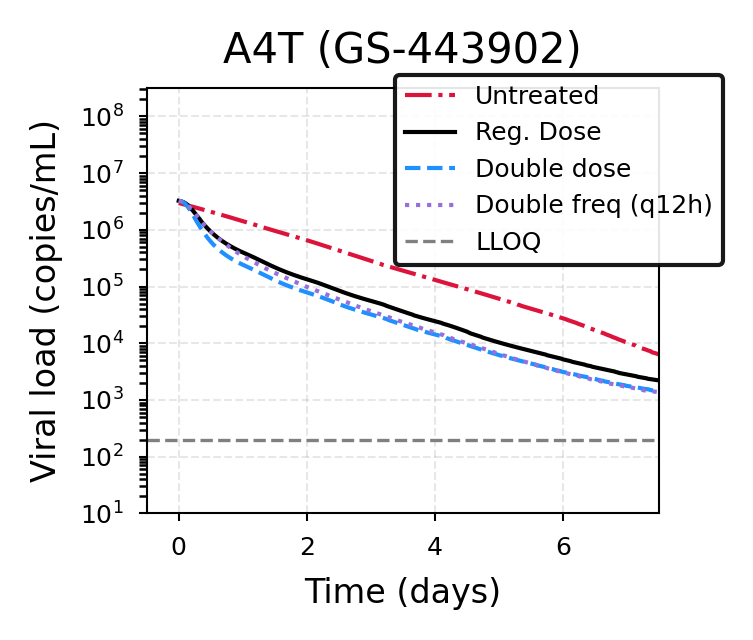

In [ ]:
# ==========================================
# 3. Execution Call
# ==========================================
generate_dosing_regimen_vl_plot(vd_df, params_df_A4T)